# __Reto 8: Visualizacion de los Datos__

## Objetivo

Extraer hallazgos de los datos a traves de visualizaciones

## Tarea 1

Cargar los datos. Vamos a trabajar con el dataset "House Prediction Rent" del reto anterior

In [1]:
# librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Tarea 2

Genera boxplots para variables de interes

__Boxplot de Rent__

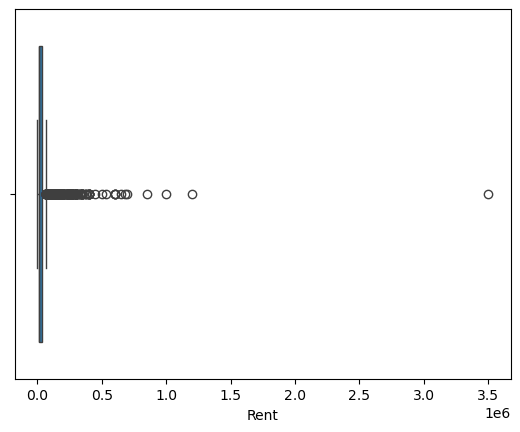

In [3]:
sns.boxplot(x=df.Rent);

> Hay rentas tan altas que escapan del comportamiento regular de la mayoria de los datos.

__Calculo del IQR para filtrar outliers__

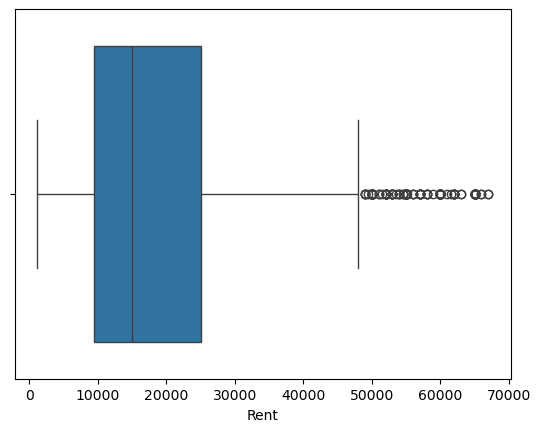

In [4]:
# Calcular cuantiles
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)

# calcular IQR
IQR = Q3 - Q1

# filtrar datos
df_filt = df[(df['Rent'] >= Q1 - 1.5*IQR) & (df['Rent'] <= Q3 + 1.5*IQR)]

# mostrar boxplot
sns.boxplot(x=df_filt['Rent']);

> El 50% de los inmuebles presenta una renta que va desde 10.000 a 25.000 aproximadamente.

> La mediana es de 15.000

__Boxplot de Size__

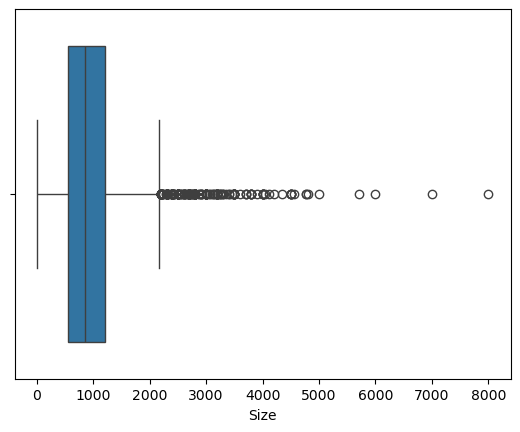

In [5]:
sns.boxplot(x=df.Size);

> Mejoremos la visualizacion del boxplot filtrando los valores extremos con IQR

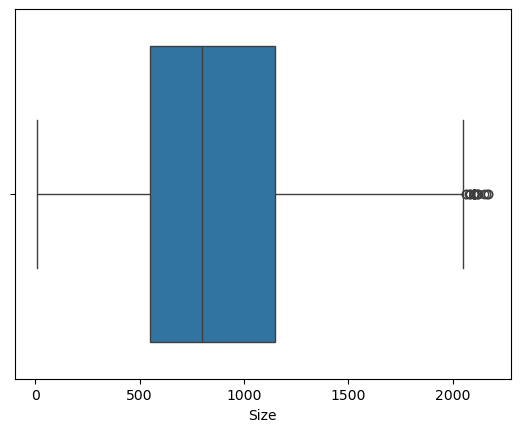

In [6]:
# Calcular cuantiles
Q1 = df['Size'].quantile(0.25)
Q3 = df['Size'].quantile(0.75)

# calcular IQR
IQR = Q3 - Q1

# filtrar datos
df_filt = df[(df['Size'] >= Q1 - 1.5*IQR) & (df['Size'] <= Q3 + 1.5*IQR)]

# mostrar boxplot
sns.boxplot(x=df_filt['Size']);

> El 50% de los inmuebles presenta un area que va desde 550 a 1200 metros cuadrados.

> La media es de aproximadamente 800 metros cuadrados.

## Tarea 3

Generar boxplot estratificado

__Boxplot de Rent basado en Area Type__

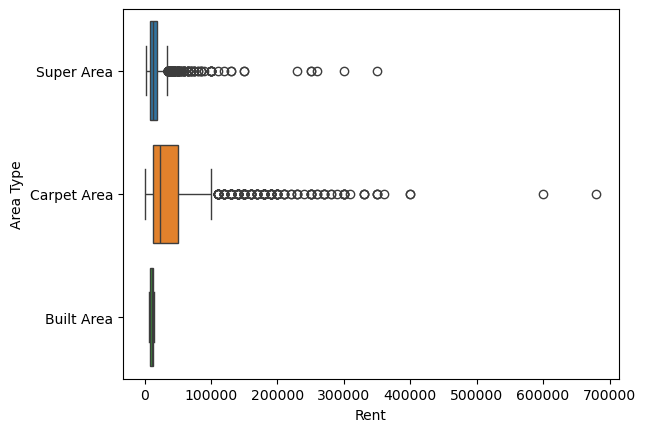

In [7]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Area Type'], hue=df_filt['Area Type']);

> Hay un mayor costo en inmuebles de tipo de area 'carpet'.

> Inmuebles de tipo 'Built' son los mas baratos.

__Boxplot de Size basado en el Area Type__

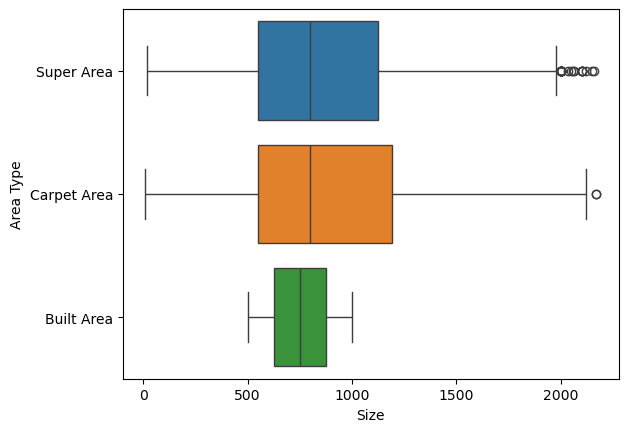

In [8]:
sns.boxplot(x=df_filt['Size'], y=df_filt['Area Type'], hue=df_filt['Area Type']);

> Super area tiende a ser mayor que el resto.

> La mayoria de inmuebles esta etre 600 y 1000 metros cuadrados.

> La variabilidad es mayor en areas Carpet que en areas construidas.

__Boxplot de Rent basado en City__

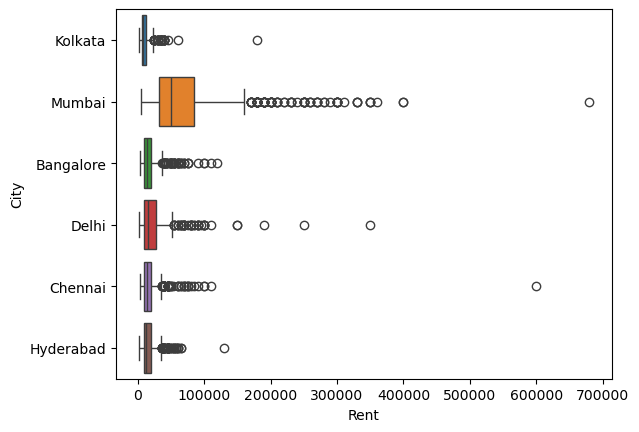

In [9]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['City'], hue=df_filt['City']);

> Usamos los datos filtrados de outliers para tener una mejor visualizacion.

> Todas las ciudades presentan asimetria positiva dado por rentas extremadamente altas.

> Mumbai es la ciudad mas cara en promedio. Presenta una alta dispersion y varios outliers extremadamente altos.

> Delhi es la segunda ciudad mas cara. Presenta una serie de outliers menos extremos.

> La presencia de outliers en todas las ciudades sugiere la presencia de propiedades de lujo.

> El mercado inmobiliario de India se encuentra altamente segmentado.

__Boxplot de Rent basado en Furnishing Status__

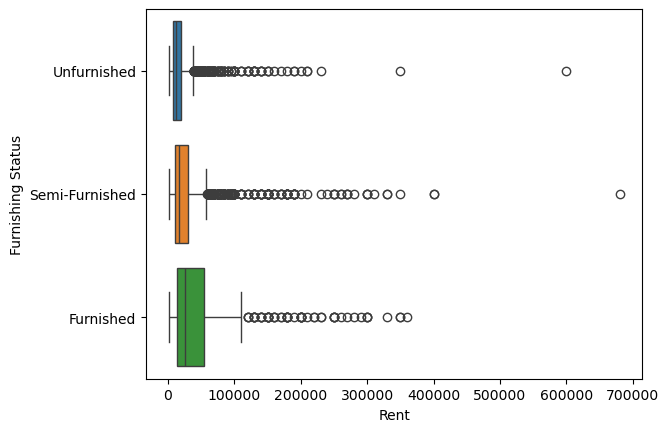

In [11]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Furnishing Status'], hue=df_filt['Furnishing Status']);

> Usamos los datos filtrados de outliers para tener una mejor visualizacion.

> Los inmuebles amueblado (Furnished) son los mas caros, en promedio. Presenta una mayor variabilidad de precio.

> Los inmuebles semi-amueblados (Semi-Furnished) se ubican en un punto medio en terminos de precio. Presentan muchos valores que siguen siendo atipicos a pesar del filtrado.

> Los inmuebles sin amueblar (Unfurnished) es la opcion mas economica y presenta una mejor variabilidad que el resto de opciones.

> Todos presentan outliers lo que sugiere propiedades muy costosas

> El nivel de amueblado si influye en el precio pero no es el unico factor determinante.

__Boxplot cruzado de Rent por City y Furnishing Status__

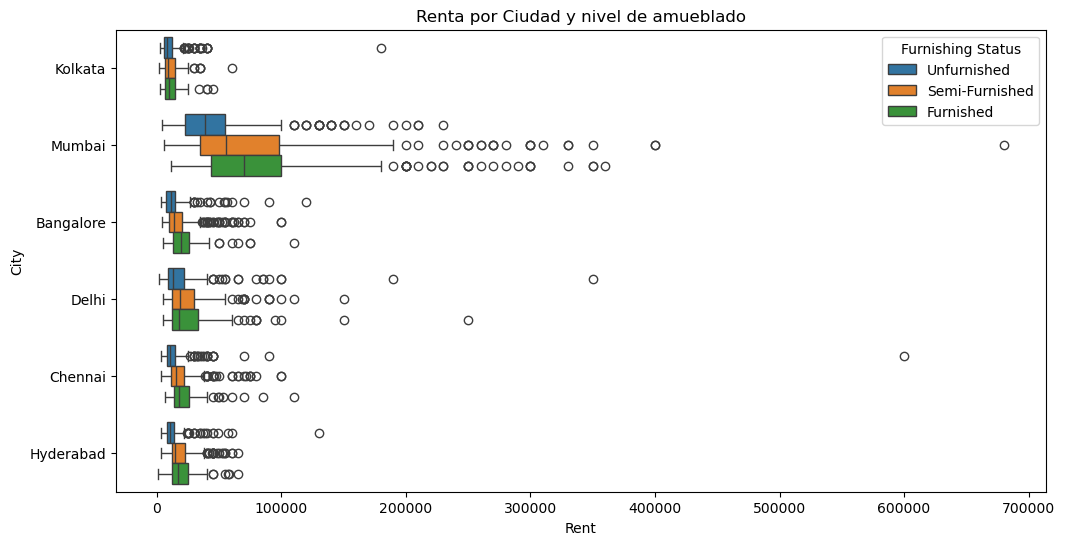

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_filt, y='City', x='Rent', hue='Furnishing Status')

plt.title('Renta por Ciudad y nivel de amueblado')
plt.show()

> En Mumbai se evidencia claramente que el amueblado si impacta fuerte en el precio.

> En ciudades como Bangalore, Chennai y Hyderabad las cajas estan muy cercanas lo que indica que el nivel de amueblado no cambia tanto el precio. Factores como ubicacion o tamano probablemente pesan mas que el amueblado.

> El amueblado agrega valor pricipalmente en mercados caros. Hay una fuerte influencia de ubicacion premium en el precio de la renta.

> Todas las ciudades presentan outliers, incluso inmuebles no amueblados lo que verifica que el precio no depende solo del amueblado.

__Boxplot de Rent basado en Tenant Preferred__

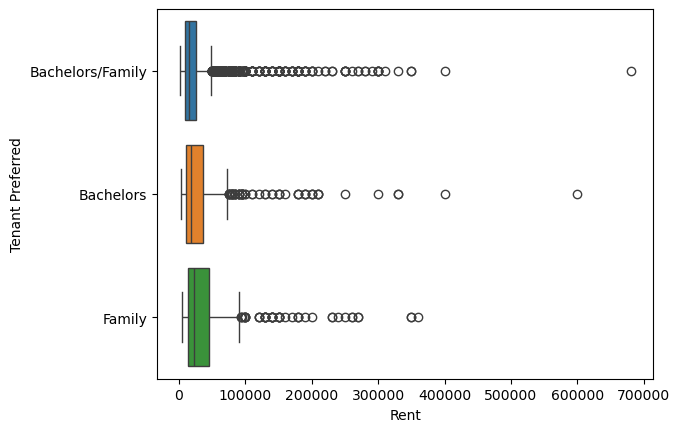

In [12]:
sns.boxplot(x=df_filt['Rent'], y=df_filt['Tenant Preferred'], hue=df_filt['Tenant Preferred']);

> 